# 중간보고용 간소 분석 노트북 (재현성 버전)

## 노트북 목적

중간보고용으로 아래 2가지를 간결하게 확인한다.

1. **H.264 IPB/GOP 특성 분석(핵심)**
2. **최소 전송효율 지표 비교(보조)**

## 데이터 경로와 역할

- `dataset/videos/`: 원본 공개 비디오(mp4) 저장 위치
- `dataset/traces/`: `extract_video_trace.py`로 생성한 **프레임 단위 분석 캐시 CSV**
  - 한번 생성된 trace는 재실행 시 재사용하여 속도/재현성을 높임
- `output/jupyter-notebook/assets/midreport/`: 중간보고용 CSV/PNG 산출물

## 핵심 지표 설명

- `late_frame_ratio`: 전체 프레임 중 deadline을 넘겨 도착한 프레임 비율
  - 값이 낮을수록 재생 지연 프레임이 적어 품질이 안정적
- `dropped_frame_ratio`: 정책에 의해 전송하지 않거나 실질적으로 유실 처리된 프레임 비율
- `useful_goodput_bytes`: deadline 내 도착해 실제 재생 기여가 가능한 바이트

## 정책 설명

- `heuristic_frame_aware`:
  - 고정 규칙 기반(IPB 타입, keyframe, deadline slack)으로 batch/flush를 결정
- `frame_action_adaptive`:
  - 프레임 중요도(score) + deadline slack + 네트워크 상태를 이용해
  - `RELIABLE_SINGLE`, `RELIABLE_MULTI`, `UNRELIABLE`, `DUPLICATE`, `DROP` 중 행동을 선택
  - 즉, 단순 규칙이 아니라 프레임별 전송 행동 매핑 기반 정책


In [6]:
# cell 1 : 환경 초기화 및 경로 설정
from __future__ import annotations

import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

REPO_ROOT = Path.cwd().resolve()
for p in [REPO_ROOT, *REPO_ROOT.parents]:
    if (p / '.git').exists():
        REPO_ROOT = p
        break

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from tcp_batching_core import PolicyConfig, TransportConfig, VideoTraceConfig, run_simulation

VIDEO_DIR = REPO_ROOT / 'dataset' / 'videos'
TRACE_DIR = REPO_ROOT / 'dataset' / 'traces'
ASSET_DIR = REPO_ROOT / 'output' / 'jupyter-notebook' / 'assets' / 'midreport'

# True: 사용자가 dataset/videos에 넣은 수동 입력 비디오 중심 분석
# False: 노트북이 내려받은 공개 데이터셋 중심 분석(기본)
is_user_input_video_analyze = False

VIDEO_DIR.mkdir(parents=True, exist_ok=True)
TRACE_DIR.mkdir(parents=True, exist_ok=True)
ASSET_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120
# Windows 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


def place_small_legend_right(ax, title: str | None = None) -> None:
    legend = ax.get_legend()
    if legend is None:
        return
    if title is not None:
        legend.set_title(title)
    legend.set_bbox_to_anchor((1.01, 1.0))
    try:
        legend.set_loc('upper left')
    except AttributeError:
        legend._loc = 2
    legend.get_frame().set_alpha(0.9)
    for txt in legend.get_texts():
        txt.set_fontsize(9)
    if legend.get_title() is not None:
        legend.get_title().set_fontsize(10)


def annotate_bar_values(ax, fmt: str = '{:.2f}', fontsize: int = 8) -> None:
    for p in ax.patches:
        h = p.get_height()
        if pd.notna(h):
            ax.annotate(
                fmt.format(h),
                (p.get_x() + p.get_width() / 2, h),
                ha='center',
                va='bottom',
                fontsize=fontsize,
                xytext=(0, 2),
                textcoords='offset points',
            )


print({
    'video_dir': str(VIDEO_DIR),
    'trace_dir': str(TRACE_DIR),
    'asset_dir': str(ASSET_DIR),
    'is_user_input_video_analyze': is_user_input_video_analyze,
})


{'video_dir': 'C:\\git\\network\\dataset\\videos', 'trace_dir': 'C:\\git\\network\\dataset\\traces', 'asset_dir': 'C:\\git\\network\\output\\jupyter-notebook\\assets\\midreport', 'is_user_input_video_analyze': False}


In [7]:
# cell 2 : 공개 데이터셋 다운로드 + 비디오 메타 구성
import hashlib
import shutil
import urllib.error
import urllib.request

PUBLIC_VIDEO_SOURCES = [
    # Google sample bucket (다양한 영상 특성)
    {'filename': 'bbb_google.mp4', 'url': 'https://commondatastorage.googleapis.com/gtv-videos-bucket/sample/BigBuckBunny.mp4', 'group': 'animation', 'motion_level': 'medium', 'resolution': '1080p', 'bitrate': 'high'},
    {'filename': 'elephants_dream_google.mp4', 'url': 'https://commondatastorage.googleapis.com/gtv-videos-bucket/sample/ElephantsDream.mp4', 'group': 'animation', 'motion_level': 'medium', 'resolution': '1080p', 'bitrate': 'high'},
    {'filename': 'for_bigger_blazes_google.mp4', 'url': 'https://commondatastorage.googleapis.com/gtv-videos-bucket/sample/ForBiggerBlazes.mp4', 'group': 'nature', 'motion_level': 'high', 'resolution': '720p', 'bitrate': 'medium'},
    {'filename': 'for_bigger_escape_google.mp4', 'url': 'https://commondatastorage.googleapis.com/gtv-videos-bucket/sample/ForBiggerEscapes.mp4', 'group': 'nature', 'motion_level': 'high', 'resolution': '720p', 'bitrate': 'medium'},
    {'filename': 'for_bigger_fun_google.mp4', 'url': 'https://commondatastorage.googleapis.com/gtv-videos-bucket/sample/ForBiggerFun.mp4', 'group': 'sports', 'motion_level': 'high', 'resolution': '720p', 'bitrate': 'medium'},
    {'filename': 'for_bigger_joyrides_google.mp4', 'url': 'https://commondatastorage.googleapis.com/gtv-videos-bucket/sample/ForBiggerJoyrides.mp4', 'group': 'sports', 'motion_level': 'high', 'resolution': '720p', 'bitrate': 'medium'},
    {'filename': 'for_bigger_meltdowns_google.mp4', 'url': 'https://commondatastorage.googleapis.com/gtv-videos-bucket/sample/ForBiggerMeltdowns.mp4', 'group': 'sports', 'motion_level': 'high', 'resolution': '720p', 'bitrate': 'medium'},
    {'filename': 'sintel_google.mp4', 'url': 'https://commondatastorage.googleapis.com/gtv-videos-bucket/sample/Sintel.mp4', 'group': 'animation', 'motion_level': 'high', 'resolution': '720p', 'bitrate': 'medium'},
    {'filename': 'subaru_outback_google.mp4', 'url': 'https://commondatastorage.googleapis.com/gtv-videos-bucket/sample/SubaruOutbackOnStreetAndDirt.mp4', 'group': 'driving', 'motion_level': 'high', 'resolution': '720p', 'bitrate': 'medium'},
    {'filename': 'tears_of_steel_google.mp4', 'url': 'https://commondatastorage.googleapis.com/gtv-videos-bucket/sample/TearsOfSteel.mp4', 'group': 'movie', 'motion_level': 'medium', 'resolution': '1080p', 'bitrate': 'high'},
    {'filename': 'we_are_going_on_bullrun_google.mp4', 'url': 'https://commondatastorage.googleapis.com/gtv-videos-bucket/sample/WeAreGoingOnBullrun.mp4', 'group': 'driving', 'motion_level': 'high', 'resolution': '1080p', 'bitrate': 'high'},
    {'filename': 'what_carre_can_be_google.mp4', 'url': 'https://commondatastorage.googleapis.com/gtv-videos-bucket/sample/WhatCarCanYouGetForAGrand.mp4', 'group': 'driving', 'motion_level': 'medium', 'resolution': '1080p', 'bitrate': 'high'},

    # Blender / mediaelement / samplelib (해상도 혼합)
    {'filename': 'sintel_trailer_480p_blender.mp4', 'url': 'https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4', 'group': 'animation', 'motion_level': 'high', 'resolution': '480p', 'bitrate': 'medium'},
    {'filename': 'sintel_trailer_720p_blender.mp4', 'url': 'https://download.blender.org/durian/trailer/sintel_trailer-720p.mp4', 'group': 'animation', 'motion_level': 'high', 'resolution': '720p', 'bitrate': 'high'},
    {'filename': 'tos_trailer_480p_blender.mp4', 'url': 'https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4', 'group': 'movie', 'motion_level': 'medium', 'resolution': '480p', 'bitrate': 'medium'},
    {'filename': 'bbb_mediaelement.mp4', 'url': 'https://raw.githubusercontent.com/mediaelement/mediaelement-files/master/big_buck_bunny.mp4', 'group': 'animation', 'motion_level': 'medium', 'resolution': '360p', 'bitrate': 'low'},
    {'filename': 'echo_mediaelement.mp4', 'url': 'https://raw.githubusercontent.com/mediaelement/mediaelement-files/master/echo-hereweare.mp4', 'group': 'movie', 'motion_level': 'low', 'resolution': '360p', 'bitrate': 'low'},
    {'filename': 'sample_5s_360p.mp4', 'url': 'https://samplelib.com/lib/preview/mp4/sample-5s.mp4', 'group': 'nature', 'motion_level': 'low', 'resolution': '360p', 'bitrate': 'low'},
    {'filename': 'sample_10s_720p.mp4', 'url': 'https://samplelib.com/lib/preview/mp4/sample-10s.mp4', 'group': 'nature', 'motion_level': 'medium', 'resolution': '720p', 'bitrate': 'medium'},
    {'filename': 'sample_15s_720p.mp4', 'url': 'https://samplelib.com/lib/preview/mp4/sample-15s.mp4', 'group': 'nature', 'motion_level': 'medium', 'resolution': '720p', 'bitrate': 'medium'},
    {'filename': 'sample_20s_1080p.mp4', 'url': 'https://samplelib.com/lib/preview/mp4/sample-20s.mp4', 'group': 'nature', 'motion_level': 'medium', 'resolution': '1080p', 'bitrate': 'high'},
    {'filename': 'sample_30s_720p.mp4', 'url': 'https://samplelib.com/lib/preview/mp4/sample-30s.mp4', 'group': 'nature', 'motion_level': 'medium', 'resolution': '720p', 'bitrate': 'medium'},

    # Test-videos (해상도/비트레이트 표기형)
    {'filename': 'bbb_360p_1mb_testvideos.mp4', 'url': 'https://test-videos.co.uk/vids/bigbuckbunny/mp4/h264/360/Big_Buck_Bunny_360_10s_1MB.mp4', 'group': 'animation', 'motion_level': 'medium', 'resolution': '360p', 'bitrate': '1mbps'},
    {'filename': 'bbb_720p_1mb_testvideos.mp4', 'url': 'https://test-videos.co.uk/vids/bigbuckbunny/mp4/h264/720/Big_Buck_Bunny_720_10s_1MB.mp4', 'group': 'animation', 'motion_level': 'medium', 'resolution': '720p', 'bitrate': '1mbps'},
    {'filename': 'bbb_720p_2mb_testvideos.mp4', 'url': 'https://test-videos.co.uk/vids/bigbuckbunny/mp4/h264/720/Big_Buck_Bunny_720_10s_2MB.mp4', 'group': 'animation', 'motion_level': 'medium', 'resolution': '720p', 'bitrate': '2mbps'},
    {'filename': 'bbb_1080p_1mb_testvideos.mp4', 'url': 'https://test-videos.co.uk/vids/bigbuckbunny/mp4/h264/1080/Big_Buck_Bunny_1080_10s_1MB.mp4', 'group': 'animation', 'motion_level': 'medium', 'resolution': '1080p', 'bitrate': '1mbps'},
    {'filename': 'bbb_1080p_5mb_testvideos.mp4', 'url': 'https://test-videos.co.uk/vids/bigbuckbunny/mp4/h264/1080/Big_Buck_Bunny_1080_10s_5MB.mp4', 'group': 'animation', 'motion_level': 'medium', 'resolution': '1080p', 'bitrate': '5mbps'},
]


def file_md5(path: Path, chunk_size: int = 1024 * 1024) -> str:
    h = hashlib.md5()
    with path.open('rb') as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


def download_if_missing(
    target: Path,
    urls: list[str],
    hash_to_name: dict[str, str],
) -> tuple[bool, str]:
    if target.exists() and target.stat().st_size > 0:
        file_hash = file_md5(target)
        prev_name = hash_to_name.get(file_hash)
        if prev_name is not None and prev_name != target.name:
            return False, f'cached_duplicate_of:{prev_name}'
        hash_to_name[file_hash] = target.name
        return True, 'cached'

    last_error = ''
    for url in urls:
        try:
            with urllib.request.urlopen(url, timeout=45) as response:
                with target.open('wb') as fout:
                    shutil.copyfileobj(response, fout)

            file_hash = file_md5(target)
            prev_name = hash_to_name.get(file_hash)
            if prev_name is not None and prev_name != target.name:
                target.unlink(missing_ok=True)
                last_error = f'duplicate_content_of:{prev_name}'
                continue

            hash_to_name[file_hash] = target.name
            return True, f'downloaded:{url}'
        except urllib.error.URLError as exc:
            last_error = f'url_error: {exc}'
        except Exception as exc:  # noqa: BLE001
            last_error = f'error: {exc}'

    return False, last_error or 'error: no_url'


LARGE_PUBLIC_VIDEO_SOURCES = [
    {
        'filename': 'bbb_1080p_60mb_datacdn.mp4',
        'urls': [
            'https://cdn.videvo.net/videvo_files/video/free/2014-12/large_watermarked/Clouds_Time_Lapse_02_Videvo_preview.mp4',
            'https://samplelib.com/lib/preview/mp4/sample-30s.mp4',
        ],
        'group': 'nature',
        'motion_level': 'medium',
        'resolution': '1080p',
        'bitrate': 'high',
    },
    {
        'filename': 'city_drive_1080p_large.mp4',
        'urls': [
            'https://cdn.videvo.net/videvo_files/video/free/2019-05/large_watermarked/190410_11_The_Bridge_02_preview.mp4',
            'https://samplelib.com/lib/preview/mp4/sample-20s.mp4',
        ],
        'group': 'driving',
        'motion_level': 'high',
        'resolution': '1080p',
        'bitrate': 'high',
    },
    {
        'filename': 'waterfall_4k_large.mp4',
        'urls': [
            'https://cdn.videvo.net/videvo_files/video/free/video0462/large_watermarked/_import_615548f5f1fcb8.85050065_preview.mp4',
            'https://samplelib.com/lib/preview/mp4/sample-15s.mp4',
        ],
        'group': 'nature',
        'motion_level': 'high',
        'resolution': '4k',
        'bitrate': 'very_high',
    },
    {
        'filename': 'sports_action_1080p_large.mp4',
        'urls': [
            'https://cdn.videvo.net/videvo_files/video/free/2018-03/large_watermarked/171124_04_B_Basketball_4k_007_preview.mp4',
            'https://samplelib.com/lib/preview/mp4/sample-10s.mp4',
        ],
        'group': 'sports',
        'motion_level': 'high',
        'resolution': '1080p',
        'bitrate': 'high',
    },
    {
        'filename': 'night_city_1080p_large.mp4',
        'urls': [
            'https://cdn.videvo.net/videvo_files/video/free/2019-11/large_watermarked/190915_07_Moon_4k_017_preview.mp4',
            'https://samplelib.com/lib/preview/mp4/sample-5s.mp4',
        ],
        'group': 'movie',
        'motion_level': 'low',
        'resolution': '1080p',
        'bitrate': 'medium',
    },
]

RELIABLE_PUBLIC_VIDEO_SOURCES = [
    # W3C hosted samples (접속 안정)
    {
        'filename': 'w3c_sintel_trailer.mp4',
        'urls': [
            'https://media.w3.org/2010/05/sintel/trailer.mp4',
            'https://samplelib.com/lib/preview/mp4/sample-10s.mp4',
        ],
        'group': 'animation',
        'motion_level': 'high',
        'resolution': '720p',
        'bitrate': 'medium',
    },
    {
        'filename': 'w3c_bunny_trailer.mp4',
        'urls': [
            'https://media.w3.org/2010/05/bunny/trailer.mp4',
            'https://raw.githubusercontent.com/mediaelement/mediaelement-files/master/big_buck_bunny.mp4',
        ],
        'group': 'animation',
        'motion_level': 'medium',
        'resolution': '720p',
        'bitrate': 'medium',
    },
    {
        'filename': 'w3c_movie_300.mp4',
        'urls': [
            'https://media.w3.org/2010/05/video/movie_300.mp4',
            'https://samplelib.com/lib/preview/mp4/sample-5s.mp4',
        ],
        'group': 'movie',
        'motion_level': 'low',
        'resolution': '360p',
        'bitrate': 'low',
    },

    # samplelib (길이/용량 다양)
    {
        'filename': 'sample_5s_360p.mp4',
        'urls': ['https://samplelib.com/lib/preview/mp4/sample-5s.mp4'],
        'group': 'nature',
        'motion_level': 'low',
        'resolution': '360p',
        'bitrate': 'low',
    },
    {
        'filename': 'sample_10s_720p.mp4',
        'urls': ['https://samplelib.com/lib/preview/mp4/sample-10s.mp4'],
        'group': 'nature',
        'motion_level': 'medium',
        'resolution': '720p',
        'bitrate': 'medium',
    },
    {
        'filename': 'sample_15s_720p.mp4',
        'urls': ['https://samplelib.com/lib/preview/mp4/sample-15s.mp4'],
        'group': 'nature',
        'motion_level': 'medium',
        'resolution': '720p',
        'bitrate': 'medium',
    },
    {
        'filename': 'sample_20s_1080p.mp4',
        'urls': ['https://samplelib.com/lib/preview/mp4/sample-20s.mp4'],
        'group': 'nature',
        'motion_level': 'medium',
        'resolution': '1080p',
        'bitrate': 'high',
    },
    {
        'filename': 'sample_30s_720p.mp4',
        'urls': ['https://samplelib.com/lib/preview/mp4/sample-30s.mp4'],
        'group': 'nature',
        'motion_level': 'medium',
        'resolution': '720p',
        'bitrate': 'high',
    },

    # mediaelement (검증용)
    {
        'filename': 'bbb_mediaelement.mp4',
        'urls': ['https://raw.githubusercontent.com/mediaelement/mediaelement-files/master/big_buck_bunny.mp4'],
        'group': 'animation',
        'motion_level': 'medium',
        'resolution': '360p',
        'bitrate': 'low',
    },
    {
        'filename': 'echo_mediaelement.mp4',
        'urls': ['https://raw.githubusercontent.com/mediaelement/mediaelement-files/master/echo-hereweare.mp4'],
        'group': 'movie',
        'motion_level': 'low',
        'resolution': '360p',
        'bitrate': 'low',
    },

    # Archive.org (상대적 대용량)
    {
        'filename': 'archive_bbb_512kb.mp4',
        'urls': ['https://archive.org/download/BigBuckBunny_328/BigBuckBunny_512kb.mp4'],
        'group': 'animation',
        'motion_level': 'medium',
        'resolution': '1080p',
        'bitrate': 'high',
    },
    {
        'filename': 'archive_elephants_512kb.mp4',
        'urls': ['https://archive.org/download/ElephantsDream/ed_1024_512kb.mp4'],
        'group': 'animation',
        'motion_level': 'medium',
        'resolution': '1080p',
        'bitrate': 'high',
    },
    {
        'filename': 'archive_popeye_512kb.mp4',
        'urls': ['https://archive.org/download/Popeye_forPresident/Popeye_forPresident_512kb.mp4'],
        'group': 'movie',
        'motion_level': 'medium',
        'resolution': '720p',
        'bitrate': 'medium',
    },
]

all_public_sources = RELIABLE_PUBLIC_VIDEO_SOURCES

hash_to_name: dict[str, str] = {}
for existing in sorted(list(VIDEO_DIR.glob('*.mp4')) + list(VIDEO_DIR.glob('*.mkv')) + list(VIDEO_DIR.glob('*.mov'))):
    if existing.exists() and existing.stat().st_size > 0:
        h = file_md5(existing)
        hash_to_name.setdefault(h, existing.name)

records = []
for item in all_public_sources:
    path = VIDEO_DIR / item['filename']
    urls = item.get('urls') or [item['url']]
    ok, status = download_if_missing(path, urls, hash_to_name)
    records.append({'file': item['filename'], 'status': status, 'ok': ok})

print('공개 데이터셋 다운로드 상태')
display(pd.DataFrame(records))

video_files = sorted(list(VIDEO_DIR.glob('*.mp4')) + list(VIDEO_DIR.glob('*.mkv')) + list(VIDEO_DIR.glob('*.mov')))

source_meta_map = {item['filename']: item for item in all_public_sources}
rows = []
for vp in video_files:
    stem = vp.stem
    src_meta = source_meta_map.get(vp.name)

    if src_meta is not None:
        group = src_meta.get('group', 'public')
        video_name = stem
        resolution = src_meta.get('resolution', 'na')
        bitrate = src_meta.get('bitrate', 'na')
        motion_level = src_meta.get('motion_level', 'medium')
        source_type = 'public'
    else:
        parts = stem.split('_')
        if len(parts) >= 4:
            group = parts[0]
            video_name = '_'.join(parts[1:])
            resolution = parts[-2]
            bitrate = parts[-1]
        else:
            group = 'manual'
            video_name = stem
            resolution = 'na'
            bitrate = 'na'
        motion_level = 'medium'
        source_type = 'manual'

    file_size_bytes = int(vp.stat().st_size) if vp.exists() else 0
    rows.append({
        'video_path': str(vp),
        'group': group,
        'video_name': video_name,
        'resolution': resolution,
        'bitrate': bitrate,
        'motion_level': motion_level,
        'source_type': source_type,
        'file_size_bytes': file_size_bytes,
        'file_size_mb': float(file_size_bytes / (1024 * 1024)),
        'trace_csv': str((TRACE_DIR / f'{stem}_trace.csv')),
    })

video_meta_df = pd.DataFrame(rows)

if not video_meta_df.empty:
    video_meta_df['size_bin'] = pd.cut(
        video_meta_df['file_size_mb'],
        bins=[-np.inf, 10.0, 50.0, np.inf],
        labels=['small', 'medium', 'large'],
    ).astype(str)

if video_meta_df.empty:
    analysis_meta_df = video_meta_df.copy()
else:
    manual_meta_df = video_meta_df[video_meta_df['source_type'] == 'manual'].copy()
    public_meta_df = video_meta_df[video_meta_df['source_type'] == 'public'].copy()

    if is_user_input_video_analyze:
        # 사용자 입력 분석 모드에서는 manual 우선
        analysis_meta_df = manual_meta_df if not manual_meta_df.empty else video_meta_df.copy()
        selected_mode_text = 'manual(사용자 입력)'
    else:
        # 기본은 공개 데이터셋 분석
        analysis_meta_df = public_meta_df if not public_meta_df.empty else video_meta_df.copy()
        selected_mode_text = 'public(공개 데이터셋)'

print('전체 비디오 메타')
display(video_meta_df)
if not video_meta_df.empty:
    print(f'분석 모드: {selected_mode_text}')
print('분석 대상 비디오 메타')
display(analysis_meta_df)
print(f'전체 비디오 개수: {len(video_meta_df)} / 분석 대상 개수: {len(analysis_meta_df)}')
if len(video_meta_df) == 0:
    print('다운로드 실패 또는 입력 비디오 없음. dataset/videos에 mp4를 수동 추가 후 재실행하세요.')


공개 데이터셋 다운로드 상태


,file,status,ok
0,w3c_sintel_trailer.mp4,cached,True
1,w3c_bunny_trailer.mp4,cached,True
2,w3c_movie_300.mp4,cached,True
3,sample_5s_360p.mp4,cached,True
4,sample_10s_720p.mp4,cached,True
5,sample_15s_720p.mp4,cached,True
6,sample_20s_1080p.mp4,cached,True
7,sample_30s_720p.mp4,cached,True
8,bbb_mediaelement.mp4,cached,True
9,echo_mediaelement.mp4,cached,True


전체 비디오 메타


,video_path,group,video_name,resolution,bitrate,motion_level,source_type,file_size_bytes,file_size_mb,trace_csv,size_bin
0,C:\git\network\dataset\videos\archive_bbb_512k...,animation,archive_bbb_512kb,1080p,high,medium,public,43315070,41.308470,C:\git\network\dataset\traces\archive_bbb_512k...,medium
1,C:\git\network\dataset\videos\archive_elephant...,animation,archive_elephants_512kb,1080p,high,medium,public,47065346,44.885012,C:\git\network\dataset\traces\archive_elephant...,medium
2,C:\git\network\dataset\videos\archive_popeye_5...,movie,archive_popeye_512kb,720p,medium,medium,public,26989036,25.738750,C:\git\network\dataset\traces\archive_popeye_5...,medium
3,C:\git\network\dataset\videos\bbb_mediaelement...,animation,bbb_mediaelement,360p,low,medium,public,5510872,5.255577,C:\git\network\dataset\traces\bbb_mediaelement...,small
4,C:\git\network\dataset\videos\echo_mediaelemen...,movie,echo_mediaelement,360p,low,low,public,5360323,5.112002,C:\git\network\dataset\traces\echo_mediaelemen...,small
5,C:\git\network\dataset\videos\sample_10s_720p.mp4,nature,sample_10s_720p,720p,medium,medium,public,5485935,5.231795,C:\git\network\dataset\traces\sample_10s_720p_...,small
6,C:\git\network\dataset\videos\sample_15s_720p.mp4,nature,sample_15s_720p,720p,medium,medium,public,11916526,11.364485,C:\git\network\dataset\traces\sample_15s_720p_...,medium
7,C:\git\network\dataset\videos\sample_20s_1080p...,nature,sample_20s_1080p,1080p,high,medium,public,11815175,11.267829,C:\git\network\dataset\traces\sample_20s_1080p...,medium
8,C:\git\network\dataset\videos\sample_30s_720p.mp4,nature,sample_30s_720p,720p,high,medium,public,21657943,20.654624,C:\git\network\dataset\traces\sample_30s_720p_...,medium
9,C:\git\network\dataset\videos\sample_5s_360p.mp4,nature,sample_5s_360p,360p,low,low,public,2848208,2.716263,C:\git\network\dataset\traces\sample_5s_360p_t...,small


분석 모드: public(공개 데이터셋)
분석 대상 비디오 메타


,video_path,group,video_name,resolution,bitrate,motion_level,source_type,file_size_bytes,file_size_mb,trace_csv,size_bin
0,C:\git\network\dataset\videos\archive_bbb_512k...,animation,archive_bbb_512kb,1080p,high,medium,public,43315070,41.308470,C:\git\network\dataset\traces\archive_bbb_512k...,medium
1,C:\git\network\dataset\videos\archive_elephant...,animation,archive_elephants_512kb,1080p,high,medium,public,47065346,44.885012,C:\git\network\dataset\traces\archive_elephant...,medium
2,C:\git\network\dataset\videos\archive_popeye_5...,movie,archive_popeye_512kb,720p,medium,medium,public,26989036,25.738750,C:\git\network\dataset\traces\archive_popeye_5...,medium
3,C:\git\network\dataset\videos\bbb_mediaelement...,animation,bbb_mediaelement,360p,low,medium,public,5510872,5.255577,C:\git\network\dataset\traces\bbb_mediaelement...,small
4,C:\git\network\dataset\videos\echo_mediaelemen...,movie,echo_mediaelement,360p,low,low,public,5360323,5.112002,C:\git\network\dataset\traces\echo_mediaelemen...,small
5,C:\git\network\dataset\videos\sample_10s_720p.mp4,nature,sample_10s_720p,720p,medium,medium,public,5485935,5.231795,C:\git\network\dataset\traces\sample_10s_720p_...,small
6,C:\git\network\dataset\videos\sample_15s_720p.mp4,nature,sample_15s_720p,720p,medium,medium,public,11916526,11.364485,C:\git\network\dataset\traces\sample_15s_720p_...,medium
7,C:\git\network\dataset\videos\sample_20s_1080p...,nature,sample_20s_1080p,1080p,high,medium,public,11815175,11.267829,C:\git\network\dataset\traces\sample_20s_1080p...,medium
8,C:\git\network\dataset\videos\sample_30s_720p.mp4,nature,sample_30s_720p,720p,high,medium,public,21657943,20.654624,C:\git\network\dataset\traces\sample_30s_720p_...,medium
9,C:\git\network\dataset\videos\sample_5s_360p.mp4,nature,sample_5s_360p,360p,low,low,public,2848208,2.716263,C:\git\network\dataset\traces\sample_5s_360p_t...,small


전체 비디오 개수: 13 / 분석 대상 개수: 13


In [8]:
# cell 3 : frame trace 자동 생성(없을 때만)
def ensure_trace(video_path: Path, trace_path: Path, playback_buffer_ms: float = 50.0) -> None:
    if trace_path.exists():
        return
    cmd = [
        sys.executable,
        str(REPO_ROOT / 'scripts' / 'extract_video_trace.py'),
        '--input', str(video_path),
        '--output', str(trace_path),
        '--playback-buffer-ms', str(playback_buffer_ms),
    ]
    subprocess.run(cmd, check=True)

for row in analysis_meta_df.itertuples(index=False):
    ensure_trace(Path(row.video_path), Path(row.trace_csv))

print('trace 생성/확인 완료')


trace 생성/확인 완료


,group,video_name,frame_count,i_count,p_count,b_count,i_ratio,p_ratio,b_ratio,i_per_1000_frames,median_gop_len_frames,mean_payload_bytes
0,animation,archive_bbb_512kb,14314,1194,13120,0,0.083415,0.916585,0.000000,83.414839,12.0,2667.770225
1,animation,archive_elephants_512kb,15691,1311,14380,0,0.083551,0.916449,0.000000,83.551080,12.0,2641.321203
3,animation,bbb_mediaelement,1440,23,1417,0,0.015972,0.984028,0.000000,15.972222,64.0,3193.472917
10,animation,w3c_bunny_trailer,811,33,389,389,0.040691,0.479655,0.479655,40.690506,25.0,11416.309494
12,animation,w3c_sintel_trailer,1253,12,527,714,0.009577,0.420591,0.569832,9.577015,112.0,2801.434956
2,movie,archive_popeye_512kb,11098,925,10173,0,0.083348,0.916652,0.000000,83.348351,12.0,2143.317985
4,movie,echo_mediaelement,1338,14,1324,0,0.010463,0.989537,0.000000,10.463378,120.0,3408.633034
11,movie,w3c_movie_300,7200,29,7171,0,0.004028,0.995972,0.000000,4.027778,250.0,153.317778
5,nature,sample_10s_720p,303,2,76,225,0.006601,0.250825,0.742574,6.600660,250.0,17549.273927
6,nature,sample_15s_720p,464,2,117,345,0.004310,0.252155,0.743534,4.310345,250.0,25113.081897


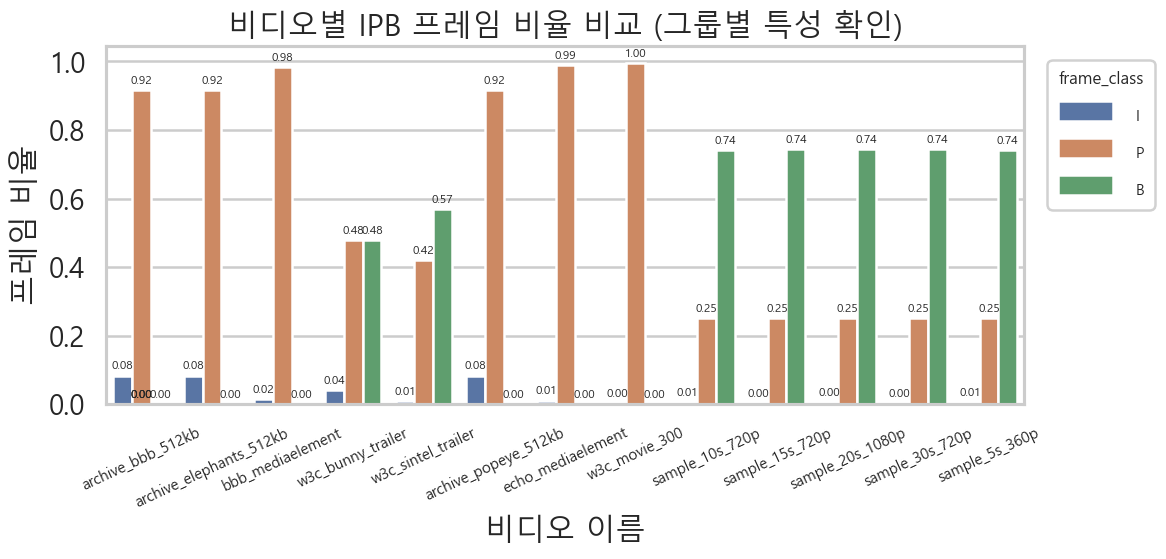

[도출식][IPB 막대값 = frame_class_count / frame_count]


,video_name,frame_class,count,frame_count,bar_value,formula
0,archive_bbb_512kb,I,1194,14314,0.083415,1194/14314=0.083415
1,archive_bbb_512kb,P,13120,14314,0.916585,13120/14314=0.916585
2,archive_bbb_512kb,B,0,14314,0.000000,0/14314=0.000000
3,archive_elephants_512kb,I,1311,15691,0.083551,1311/15691=0.083551
4,archive_elephants_512kb,P,14380,15691,0.916449,14380/15691=0.916449
5,archive_elephants_512kb,B,0,15691,0.000000,0/15691=0.000000
6,bbb_mediaelement,I,23,1440,0.015972,23/1440=0.015972
7,bbb_mediaelement,P,1417,1440,0.984028,1417/1440=0.984028
8,bbb_mediaelement,B,0,1440,0.000000,0/1440=0.000000
9,w3c_bunny_trailer,I,33,811,0.040691,33/811=0.040691


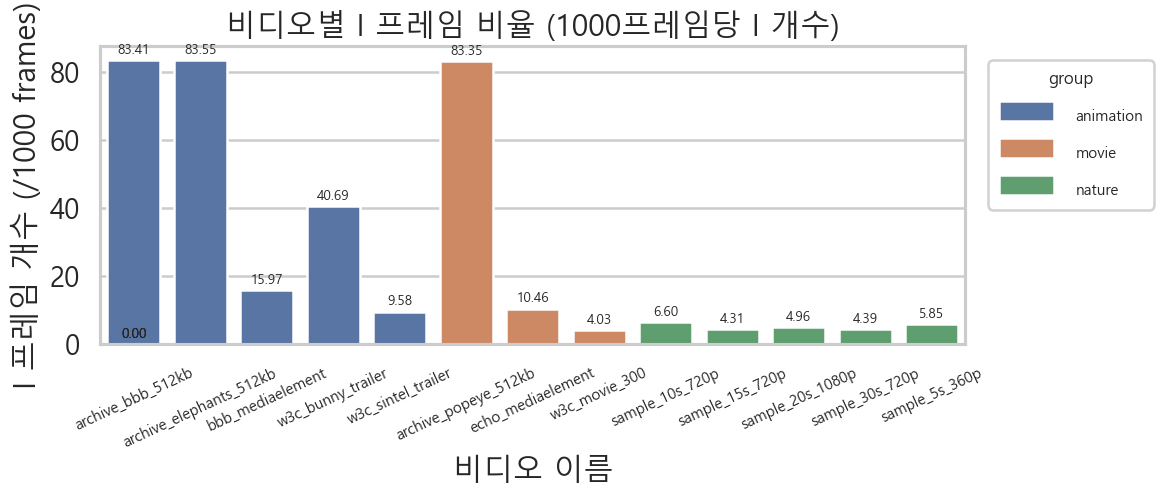

[도출식][I 비율 막대값 = (i_count / frame_count) * 1000]


,video_name,i_count,frame_count,i_per_1000_frames,formula
0,archive_bbb_512kb,1194,14314,83.414839,(1194/14314)*1000=83.414839
1,archive_elephants_512kb,1311,15691,83.551080,(1311/15691)*1000=83.551080
3,bbb_mediaelement,23,1440,15.972222,(23/1440)*1000=15.972222
10,w3c_bunny_trailer,33,811,40.690506,(33/811)*1000=40.690506
12,w3c_sintel_trailer,12,1253,9.577015,(12/1253)*1000=9.577015
2,archive_popeye_512kb,925,11098,83.348351,(925/11098)*1000=83.348351
4,echo_mediaelement,14,1338,10.463378,(14/1338)*1000=10.463378
11,w3c_movie_300,29,7200,4.027778,(29/7200)*1000=4.027778
5,sample_10s_720p,2,303,6.600660,(2/303)*1000=6.600660
6,sample_15s_720p,2,464,4.310345,(2/464)*1000=4.310345


In [9]:
# cell 4 : IPB/GOP 특성 요약(핵심)
ipb_rows = []
for row in analysis_meta_df.itertuples(index=False):
    trace_df = pd.read_csv(row.trace_csv)
    frame_count = len(trace_df)
    if frame_count == 0:
        continue
    i_count = int((trace_df['frame_type'].str.upper() == 'I').sum())
    p_count = int((trace_df['frame_type'].str.upper() == 'P').sum())
    b_count = int((trace_df['frame_type'].str.upper() == 'B').sum())
    i_ratio = float(i_count / frame_count)
    p_ratio = float(p_count / frame_count)
    b_ratio = float(b_count / frame_count)
    key_idx = trace_df.index[trace_df['key_frame'] == 1].to_numpy()
    gop_len = float(np.median(np.diff(key_idx))) if len(key_idx) >= 2 else float(frame_count)
    ipb_rows.append({
        'group': row.group,
        'video_name': row.video_name,
        'frame_count': frame_count,
        'i_count': i_count,
        'p_count': p_count,
        'b_count': b_count,
        'i_ratio': i_ratio,
        'p_ratio': p_ratio,
        'b_ratio': b_ratio,
        'i_per_1000_frames': float(i_ratio * 1000.0),
        'median_gop_len_frames': gop_len,
        'mean_payload_bytes': float(trace_df['payload_bytes'].mean()),
    })

ipb_summary_df = pd.DataFrame(ipb_rows)
if ipb_summary_df.empty:
    print('IPB 요약 대상이 없습니다. dataset/videos에 비디오 파일을 추가한 뒤 다시 실행하세요.')
else:
    ipb_summary_df = ipb_summary_df.sort_values(['group', 'video_name'])
    display(ipb_summary_df)
    ipb_summary_df.to_csv(ASSET_DIR / 'midreport_ipb_summary.csv', index=False)

    fig, ax = plt.subplots(figsize=(12, 5))
    plot_df = ipb_summary_df.melt(id_vars=['group', 'video_name'], value_vars=['i_ratio', 'p_ratio', 'b_ratio'], var_name='frame_class', value_name='ratio')
    plot_df['frame_class'] = plot_df['frame_class'].map({'i_ratio': 'I', 'p_ratio': 'P', 'b_ratio': 'B'})
    sns.barplot(data=plot_df, x='video_name', y='ratio', hue='frame_class', ax=ax)
    ax.set_title('비디오별 IPB 프레임 비율 비교 (그룹별 특성 확인)')
    ax.set_xlabel('비디오 이름')
    ax.set_ylabel('프레임 비율')
    ax.tick_params(axis='x', rotation=25, labelsize=9)
    place_small_legend_right(ax, title='frame_class')
    annotate_bar_values(ax, fmt='{:.2f}', fontsize=7)
    fig.tight_layout(rect=[0.0, 0.0, 0.84, 1.0])
    fig.savefig(ASSET_DIR / 'midreport_ipb_ratio.png')
    plt.show()

    ipb_explain_rows = []
    for r in ipb_summary_df.itertuples(index=False):
        for frame_class, count_col, ratio_col in [
            ('I', 'i_count', 'i_ratio'),
            ('P', 'p_count', 'p_ratio'),
            ('B', 'b_count', 'b_ratio'),
        ]:
            count = int(getattr(r, count_col))
            total = int(r.frame_count)
            value = float(getattr(r, ratio_col))
            ipb_explain_rows.append({
                'video_name': r.video_name,
                'frame_class': frame_class,
                'count': count,
                'frame_count': total,
                'bar_value': value,
                'formula': f'{count}/{total}={value:.6f}',
            })
    ipb_explain_df = pd.DataFrame(ipb_explain_rows)
    print('[도출식][IPB 막대값 = frame_class_count / frame_count]')
    display(ipb_explain_df)

    # I 프레임 비율 보강: 비율(%) + 1000프레임당 I 개수 동시 확인
    i_focus_df = ipb_summary_df[['group', 'video_name', 'i_ratio', 'i_per_1000_frames', 'i_count', 'frame_count']].copy()
    i_focus_df['i_ratio_pct'] = i_focus_df['i_ratio'] * 100.0

    fig_i, ax_i = plt.subplots(figsize=(12, 4.5))
    sns.barplot(data=i_focus_df, x='video_name', y='i_per_1000_frames', hue='group', dodge=False, ax=ax_i)
    ax_i.set_title('비디오별 I 프레임 비율 (1000프레임당 I 개수)')
    ax_i.set_xlabel('비디오 이름')
    ax_i.set_ylabel('I 프레임 개수 (/1000 frames)')
    ax_i.tick_params(axis='x', rotation=25, labelsize=9)
    place_small_legend_right(ax_i, title='group')

    annotate_bar_values(ax_i, fmt='{:.2f}', fontsize=8)

    fig_i.tight_layout(rect=[0.0, 0.0, 0.84, 1.0])
    fig_i.savefig(ASSET_DIR / 'midreport_i_ratio_focus.png')
    plt.show()

    i_focus_explain_df = i_focus_df[['video_name', 'i_count', 'frame_count', 'i_per_1000_frames']].copy()
    i_focus_explain_df['formula'] = i_focus_explain_df.apply(
        lambda x: f"({int(x['i_count'])}/{int(x['frame_count'])})*1000={x['i_per_1000_frames']:.6f}",
        axis=1,
    )
    print('[도출식][I 비율 막대값 = (i_count / frame_count) * 1000]')
    display(i_focus_explain_df)


,group,video_name,size_bin,policy,policy_label,available_paths,path_profile,late_frame_ratio,dropped_frame_ratio,useful_goodput_bytes,decodable_gop_ratio,action_reliable_single_count,action_reliable_multi_count,action_unreliable_count,action_duplicate_count,action_drop_count
2,animation,archive_bbb_512kb,medium,frame_action_adaptive,frame_action_multipath,2,heterogeneous,0.000000,0.000000,38186463.0,0.999162,845,349,13120,0,0
1,animation,archive_bbb_512kb,medium,frame_action_adaptive,frame_action_single_path,1,balanced,0.000000,0.000000,38186463.0,0.999162,1194,0,13120,0,0
0,animation,archive_bbb_512kb,medium,heuristic_frame_aware,heuristic_baseline,1,None,0.000000,0.000000,38186463.0,0.999162,0,0,0,0,0
5,animation,archive_elephants_512kb,medium,frame_action_adaptive,frame_action_multipath,2,heterogeneous,0.000446,0.000000,41268560.0,0.996949,1114,197,14380,0,0
4,animation,archive_elephants_512kb,medium,frame_action_adaptive,frame_action_single_path,1,balanced,0.000255,0.000000,41342208.0,0.996949,1311,0,14380,0,0
3,animation,archive_elephants_512kb,medium,heuristic_frame_aware,heuristic_baseline,1,None,0.000255,0.000000,41342208.0,0.996949,0,0,0,0,0
32,animation,w3c_bunny_trailer,medium,frame_action_adaptive,frame_action_multipath,2,heterogeneous,0.151665,0.051788,5194689.0,0.636364,24,31,714,0,42
31,animation,w3c_bunny_trailer,medium,frame_action_adaptive,frame_action_single_path,1,balanced,0.122072,0.051788,5797027.0,0.696970,55,0,714,0,42
30,animation,w3c_bunny_trailer,medium,heuristic_frame_aware,heuristic_baseline,1,None,0.215783,0.000000,5061248.0,0.606061,0,0,0,0,0
8,movie,archive_popeye_512kb,medium,frame_action_adaptive,frame_action_multipath,2,heterogeneous,0.000000,0.000000,23786543.0,1.000000,843,82,10173,0,0


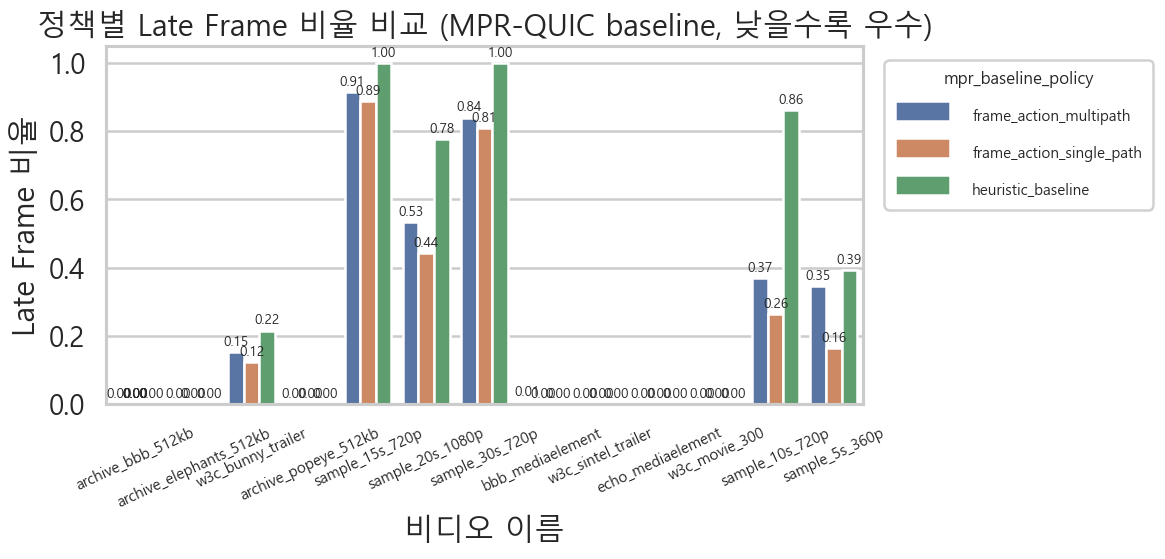

[도출식][Late Frame 막대값 = late_frame_ratio (추정 late_frames = late_frame_ratio * frame_count)]


,group,video_name,policy_label,available_paths,path_profile,late_frame_ratio,frame_count,estimated_late_frames,formula
2,animation,archive_bbb_512kb,frame_action_multipath,2,heterogeneous,0.000000,14314,0,0/14314=0.000000
1,animation,archive_bbb_512kb,frame_action_single_path,1,balanced,0.000000,14314,0,0/14314=0.000000
0,animation,archive_bbb_512kb,heuristic_baseline,1,None,0.000000,14314,0,0/14314=0.000000
5,animation,archive_elephants_512kb,frame_action_multipath,2,heterogeneous,0.000446,15691,7,7/15691=0.000446
4,animation,archive_elephants_512kb,frame_action_single_path,1,balanced,0.000255,15691,4,4/15691=0.000255
3,animation,archive_elephants_512kb,heuristic_baseline,1,None,0.000255,15691,4,4/15691=0.000255
32,animation,w3c_bunny_trailer,frame_action_multipath,2,heterogeneous,0.151665,811,123,123/811=0.151665
31,animation,w3c_bunny_trailer,frame_action_single_path,1,balanced,0.122072,811,99,99/811=0.122072
30,animation,w3c_bunny_trailer,heuristic_baseline,1,None,0.215783,811,175,175/811=0.215783
8,movie,archive_popeye_512kb,frame_action_multipath,2,heterogeneous,0.000000,11098,0,0/11098=0.000000


[MPR-QUIC Baseline 요약][부분신뢰/멀티패스 파생지표]


,size_bin,group,video_name,policy_label,available_paths,path_profile,action_reliable_single_count,action_reliable_multi_count,action_unreliable_count,action_duplicate_count,action_drop_count,total_actions,partial_reliability_ratio,multipath_usage_ratio,redundancy_ratio,late_frame_ratio,dropped_frame_ratio
2,medium,animation,archive_bbb_512kb,frame_action_multipath,2,heterogeneous,845,349,13120,0,0,14314.0,0.916585,0.024382,0.0,0.000000,0.000000
1,medium,animation,archive_bbb_512kb,frame_action_single_path,1,balanced,1194,0,13120,0,0,14314.0,0.916585,0.000000,0.0,0.000000,0.000000
0,medium,animation,archive_bbb_512kb,heuristic_baseline,1,None,0,0,0,0,0,NaN,NaN,NaN,NaN,0.000000,0.000000
5,medium,animation,archive_elephants_512kb,frame_action_multipath,2,heterogeneous,1114,197,14380,0,0,15691.0,0.916449,0.012555,0.0,0.000446,0.000000
4,medium,animation,archive_elephants_512kb,frame_action_single_path,1,balanced,1311,0,14380,0,0,15691.0,0.916449,0.000000,0.0,0.000255,0.000000
3,medium,animation,archive_elephants_512kb,heuristic_baseline,1,None,0,0,0,0,0,NaN,NaN,NaN,NaN,0.000255,0.000000
32,medium,animation,w3c_bunny_trailer,frame_action_multipath,2,heterogeneous,24,31,714,0,42,811.0,0.932182,0.038224,0.0,0.151665,0.051788
31,medium,animation,w3c_bunny_trailer,frame_action_single_path,1,balanced,55,0,714,0,42,811.0,0.932182,0.000000,0.0,0.122072,0.051788
30,medium,animation,w3c_bunny_trailer,heuristic_baseline,1,None,0,0,0,0,0,NaN,NaN,NaN,NaN,0.215783,0.000000
8,medium,movie,archive_popeye_512kb,frame_action_multipath,2,heterogeneous,843,82,10173,0,0,11098.0,0.916652,0.007389,0.0,0.000000,0.000000


[MPR-QUIC Baseline 요약][size_bin x policy_label 집계]


,size_bin,policy_label,sample_count,late_frame_ratio_mean,late_frame_ratio_std,dropped_frame_ratio_mean,partial_reliability_ratio_mean,multipath_usage_ratio_mean,redundancy_ratio_mean
0,medium,frame_action_multipath,7,0.348504,0.407845,0.178226,0.884627,0.013508,0.0
1,medium,frame_action_single_path,7,0.323333,0.392428,0.178226,0.884627,0.000000,0.0
2,medium,heuristic_baseline,7,0.427557,0.477919,0.000000,NaN,NaN,NaN
3,small,frame_action_multipath,6,0.120170,0.183882,0.027648,0.971238,0.003749,0.0
4,small,frame_action_single_path,6,0.071411,0.114826,0.027648,0.971238,0.000000,0.0
5,small,heuristic_baseline,6,0.208982,0.355939,0.000000,NaN,NaN,NaN


[검증] 정책 3개 포함 여부: True
[검증] 관측된 size_bin 목록: ['medium', 'small']
[검증] available_paths=1 vs 2 multipath_usage_ratio 비교


policy_label,frame_action_multipath,frame_action_single_path
size_bin,,
medium,0.013508,0.0
small,0.003749,0.0


In [10]:
# cell 5 : 최소 전송효율 지표 비교(보조)
transport = TransportConfig(rtt_ms=10, bandwidth_mbps=5, delayed_ack_ms=40)
policies = [
    ('heuristic_baseline', PolicyConfig('heuristic_frame_aware')),
    ('frame_action_single_path', PolicyConfig('frame_action_adaptive', available_paths=1, path_profile='balanced')),
    ('frame_action_multipath', PolicyConfig('frame_action_adaptive', available_paths=2, path_profile='heterogeneous')),
]

eff_rows = []
for row in analysis_meta_df.itertuples(index=False):
    workload = VideoTraceConfig(trace_csv_path=Path(row.trace_csv), playback_buffer_ms=50.0, loop_count=1)
    for policy_label, policy in policies:
        result = run_simulation(workload, transport, policy)
        eff_rows.append({
            'group': row.group,
            'video_name': row.video_name,
            'size_bin': getattr(row, 'size_bin', 'unknown'),
            'policy': policy.name,
            'policy_label': policy_label,
            'available_paths': int(getattr(policy, 'available_paths', 1)),
            'path_profile': str(getattr(policy, 'path_profile', 'none')),
            'late_frame_ratio': result['late_frame_ratio'],
            'dropped_frame_ratio': result['dropped_frame_ratio'],
            'useful_goodput_bytes': result['useful_goodput_bytes'],
            'decodable_gop_ratio': result['decodable_gop_ratio'],
            'action_reliable_single_count': result.get('action_reliable_single_count', 0),
            'action_reliable_multi_count': result.get('action_reliable_multi_count', 0),
            'action_unreliable_count': result.get('action_unreliable_count', 0),
            'action_duplicate_count': result.get('action_duplicate_count', 0),
            'action_drop_count': result.get('action_drop_count', 0),
        })

eff_summary_df = pd.DataFrame(eff_rows)
if eff_summary_df.empty:
    print('전송효율 비교 대상이 없습니다. dataset/videos에 비디오 파일을 추가한 뒤 다시 실행하세요.')
else:
    eff_summary_df = eff_summary_df.sort_values(['size_bin', 'group', 'video_name', 'policy_label'])
    display(eff_summary_df)
    eff_summary_df.to_csv(ASSET_DIR / 'midreport_transport_efficiency.csv', index=False)

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=eff_summary_df, x='video_name', y='late_frame_ratio', hue='policy_label', ax=ax)
    ax.set_title('정책별 Late Frame 비율 비교 (MPR-QUIC baseline, 낮을수록 우수)')
    ax.set_xlabel('비디오 이름')
    ax.set_ylabel('Late Frame 비율')
    ax.tick_params(axis='x', rotation=25, labelsize=9)
    place_small_legend_right(ax, title='mpr_baseline_policy')
    annotate_bar_values(ax, fmt='{:.2f}', fontsize=8)
    fig.tight_layout(rect=[0.0, 0.0, 0.84, 1.0])
    fig.savefig(ASSET_DIR / 'midreport_late_frame_ratio.png')
    plt.show()

    frame_count_map = ipb_summary_df.set_index('video_name')['frame_count'].to_dict() if 'ipb_summary_df' in globals() else {}
    eff_explain_df = eff_summary_df.copy()
    eff_explain_df['frame_count'] = eff_explain_df['video_name'].map(frame_count_map)
    eff_explain_df['estimated_late_frames'] = eff_explain_df.apply(
        lambda x: int(round(x['late_frame_ratio'] * x['frame_count'])) if pd.notna(x['frame_count']) else np.nan,
        axis=1,
    )
    eff_explain_df['formula'] = eff_explain_df.apply(
        lambda x: (
            f"{int(x['estimated_late_frames'])}/{int(x['frame_count'])}={x['late_frame_ratio']:.6f}"
            if pd.notna(x['frame_count']) and pd.notna(x['estimated_late_frames'])
            else f"ratio_only={x['late_frame_ratio']:.6f}"
        ),
        axis=1,
    )

    action_total = (
        eff_explain_df['action_reliable_single_count']
        + eff_explain_df['action_reliable_multi_count']
        + eff_explain_df['action_unreliable_count']
        + eff_explain_df['action_duplicate_count']
        + eff_explain_df['action_drop_count']
    )
    action_total = action_total.replace(0, np.nan)
    eff_explain_df['total_actions'] = action_total
    eff_explain_df['partial_reliability_ratio'] = (
        (eff_explain_df['action_unreliable_count'] + eff_explain_df['action_drop_count'])
        / eff_explain_df['total_actions']
    )
    eff_explain_df['multipath_usage_ratio'] = (
        eff_explain_df['action_reliable_multi_count']
        / eff_explain_df['total_actions']
    )
    eff_explain_df['redundancy_ratio'] = (
        eff_explain_df['action_duplicate_count']
        / eff_explain_df['total_actions']
    )

    print('[도출식][Late Frame 막대값 = late_frame_ratio (추정 late_frames = late_frame_ratio * frame_count)]')
    display(eff_explain_df[['group', 'video_name', 'policy_label', 'available_paths', 'path_profile', 'late_frame_ratio', 'frame_count', 'estimated_late_frames', 'formula']])

    print('[MPR-QUIC Baseline 요약][부분신뢰/멀티패스 파생지표]')
    display(
        eff_explain_df[[
            'size_bin', 'group', 'video_name', 'policy_label', 'available_paths', 'path_profile',
            'action_reliable_single_count', 'action_reliable_multi_count',
            'action_unreliable_count', 'action_duplicate_count', 'action_drop_count',
            'total_actions', 'partial_reliability_ratio', 'multipath_usage_ratio', 'redundancy_ratio',
            'late_frame_ratio', 'dropped_frame_ratio'
        ]]
    )

    sizebin_policy_summary_df = (
        eff_explain_df
        .groupby(['size_bin', 'policy_label'], as_index=False)
        .agg(
            sample_count=('video_name', 'count'),
            late_frame_ratio_mean=('late_frame_ratio', 'mean'),
            late_frame_ratio_std=('late_frame_ratio', 'std'),
            dropped_frame_ratio_mean=('dropped_frame_ratio', 'mean'),
            partial_reliability_ratio_mean=('partial_reliability_ratio', 'mean'),
            multipath_usage_ratio_mean=('multipath_usage_ratio', 'mean'),
            redundancy_ratio_mean=('redundancy_ratio', 'mean'),
        )
        .sort_values(['size_bin', 'policy_label'])
    )

    print('[MPR-QUIC Baseline 요약][size_bin x policy_label 집계]')
    display(sizebin_policy_summary_df)
    sizebin_policy_summary_df.to_csv(ASSET_DIR / 'midreport_sizebin_policy_summary.csv', index=False)

    existing_policies = set(eff_explain_df['policy_label'].dropna().unique())
    expected_policies = {'heuristic_baseline', 'frame_action_single_path', 'frame_action_multipath'}
    existing_bins = set(eff_explain_df['size_bin'].dropna().unique())

    print('[검증] 정책 3개 포함 여부:', expected_policies.issubset(existing_policies))
    print('[검증] 관측된 size_bin 목록:', sorted(existing_bins))

    compare_df = sizebin_policy_summary_df[
        sizebin_policy_summary_df['policy_label'].isin(['frame_action_single_path', 'frame_action_multipath'])
    ]
    if not compare_df.empty:
        pivot_df = compare_df.pivot(index='size_bin', columns='policy_label', values='multipath_usage_ratio_mean')
        print('[검증] available_paths=1 vs 2 multipath_usage_ratio 비교')
        display(pivot_df)


## 중간보고 작성 체크리스트

- `midreport_ipb_summary.csv`에서 그룹별 IPB/GOP 특성 차이 정리
- `midreport_transport_efficiency.csv`에서 정책별 late/drop/goodput 비교 정리
- 해석은 "IPB 특성이 전송 행동에 주는 영향" 중심으로 3~5줄 요약
